In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the location dataset

data_path = "../data/interim/location_data.csv"

df_reader = pd.read_csv(data_path, chunksize=100000)

df_reader

In [ ]:
# do sampling

all_samples = []

df_reader = pd.read_csv(data_path, chunksize=100000)

for df in df_reader:
    all_samples.append(df.sample(500))


sample_df = pd.concat(all_samples, axis=0)

In [ ]:
# size of sample df

sample_df.shape

(166500, 2)

In [ ]:
sample_df

,pickup_latitude,pickup_longitude
51084,40.751678,-73.990219
66536,40.724678,-74.007713
96557,40.729874,-73.980873
6246,40.741447,-73.993027
38272,40.745640,-73.957199
...,...,...
33215460,40.760475,-73.985428
33207257,40.723927,-73.996979
33215170,40.727467,-74.000748
33204206,40.728123,-73.988243


Text(0, 0.5, 'Longitude')

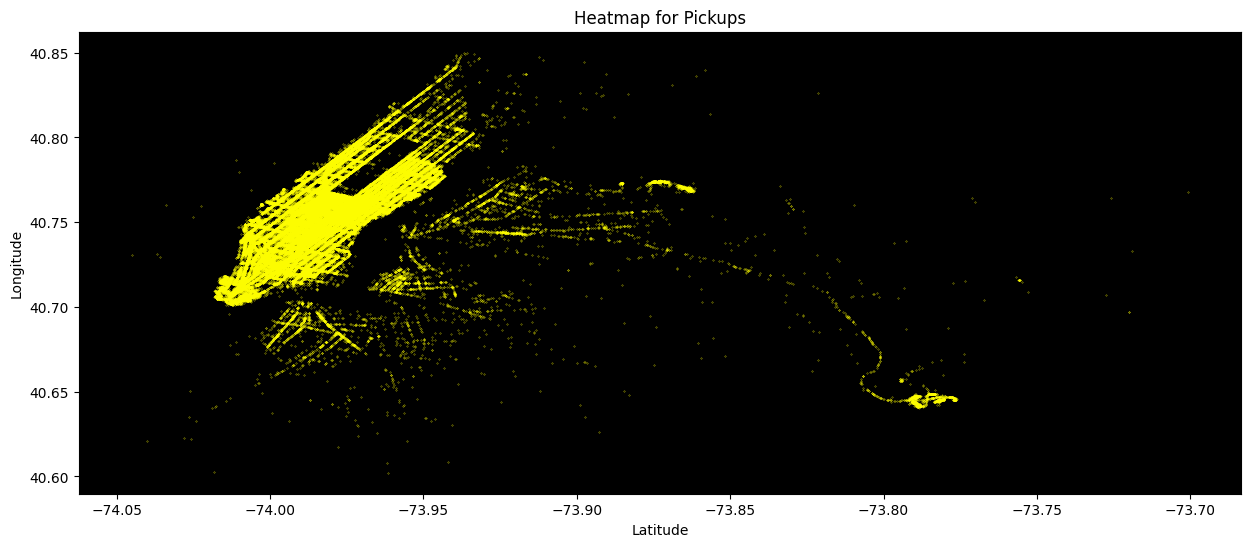

In [ ]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(sample_df['pickup_longitude'],sample_df['pickup_latitude'],s=0.05,color='yellow')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

In [ ]:
from sklearn import set_config

set_config(transform_output='pandas')

In [ ]:
# scale the input columns

from sklearn.preprocessing import StandardScaler

scale_samples = StandardScaler()

scaled_sample_df = scale_samples.fit_transform(sample_df)

In [ ]:
scaled_sample_df

,pickup_latitude,pickup_longitude
51084,0.022336,-0.440515
66536,-0.968909,-0.913160
96557,-0.778167,-0.188012
6246,-0.353267,-0.516369
38272,-0.199357,0.451595
...,...,...
33215460,0.345282,-0.311068
33207257,-0.996498,-0.623142
33215170,-0.866536,-0.724968
33204206,-0.842448,-0.387129


Text(0, 0.5, 'Longitude')

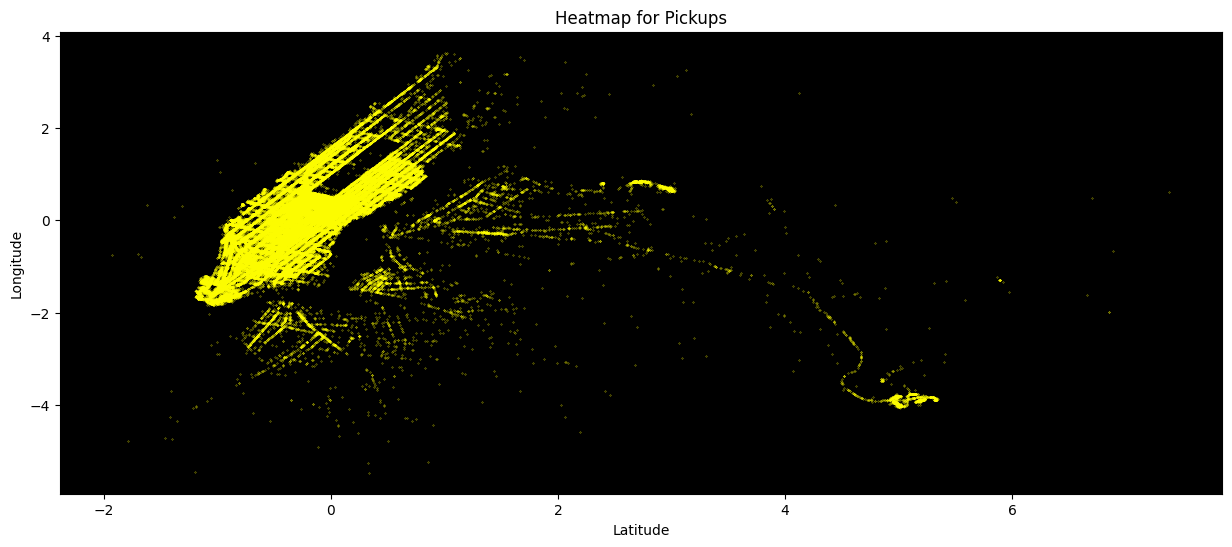

In [ ]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(scaled_sample_df['pickup_longitude'],scaled_sample_df['pickup_latitude'],s=0.05,color='yellow')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df_reader = pd.read_csv(data_path, chunksize=100000)

In [ ]:
# train the standard scaler

scaler = StandardScaler()

for chunk in df_reader:
    # fit the scaler
    scaler.partial_fit(chunk)

In [ ]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [ ]:
# get the scaler std and mean

print("The mean values are ", scaler.mean_)
print("The sigma values are ", scaler.scale_ )

The mean values are  [ 40.75107121 -73.9740618 ]
The sigma values are  [0.02722268 0.03675237]


In [ ]:
def haversine_distance(lat1:float, lon1:float, lat2:float, lon2:float):
    """
    Calculate haversine distances between two points given their latitude and
    longitude coordinates
    """
    
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    
    earth_radius = 3958.8
    distance = earth_radius * c
    return distance

In [ ]:
def select_optimum_k(k_values):
    for k in k_values:
        df_reader = pd.read_csv(data_path, chunksize=100000)
        mini_batch = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
        
        for chunk in df_reader:
            # scale the chunk
            scaled_chunk = scaler.transform(chunk)
            # train the model
            mini_batch.partial_fit(scaled_chunk)
            
        # centroid values
        centroids = scaler.inverse_transform(mini_batch.cluster_centers_)
        # calculate distances
        all_distances = []
        for i in centroids:
            distances = []
            for j in centroids:
                distance = haversine_distance(i[0], i[1], j[0], j[1])
                distances.append(distance)
            all_distances.append(distances)
        all_distances = np.array(all_distances)
        # sort array
        sorted_distances = np.sort(all_distances, axis=-1)
        # nearby regions
        region_count = 8
        # selected distances
        selected_distances = sorted_distances[:, 1:region_count+1]
        # average distances
        avg_distances = selected_distances.mean(axis=1)
        # count averages that fit criteria
        counter = ((avg_distances >= 1.0) & (avg_distances <= 1.5)).sum()
        percentage = ((avg_distances >= 1.0) & (avg_distances <= 1.5)).mean()
        print(f"For {k} clusters, the number of nearby regions that fits criteria are {counter} and is {percentage * 100:.1f}% regions of total")

In [ ]:
#possible_k_values = np.arange(10,100,1)

possible_k_values

NameError: name 'possible_k_values' is not defined

In [ ]:
# select the optimum value of K

#select_optimum_k(k_values=possible_k_values)

For 10 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 11 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 12 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 13 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 14 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 15 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 16 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 17 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 18 clusters, the number of nearby regions that fits criteria are 2 and is 11.1% regions of total
For 19 clusters, the number of nearby regions that fits criteria are 2 and is 10.5% regions of tota

In [ ]:
df_reader = pd.read_csv(data_path, chunksize=100000)
mini_batch = MiniBatchKMeans(n_clusters=24, n_init=10, random_state=42)

for chunk in df_reader:
    # scale the chunk
    scaled_chunk = scaler.transform(chunk)
    # train the model
    mini_batch.partial_fit(scaled_chunk)
    
# centroid values
centroids = mini_batch.cluster_centers_

centroids

array([[ 1.93366975,  0.70759895],
       [-0.09740296, -0.11536132],
       [-2.31919567,  1.13434475],
       [-3.83593206,  5.15082603],
       [-1.16043023, -0.82805942],
       [ 0.35259322, -0.19044797],
       [ 0.71748473,  2.8582412 ],
       [-0.51886268, -0.334922  ],
       [ 1.0707759 ,  0.56549965],
       [-2.52396327, -0.25774249],
       [-0.98831971, -0.41490995],
       [ 0.95216365, -0.20284667],
       [-0.29649198, -0.71985199],
       [ 0.14492739,  1.38880613],
       [ 0.04601104, -0.4723798 ],
       [ 1.30193457, -0.01943776],
       [-1.31609616,  0.5278593 ],
       [ 2.79419018,  0.81688511],
       [ 0.31244305,  0.12798165],
       [ 0.54874398, -0.37828537],
       [-1.55263904, -0.99580397],
       [ 0.68134617,  0.40195662],
       [-0.71598084, -0.75616428],
       [ 1.70006217,  0.1723838 ]])

In [ ]:
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

centroids.shape

centroids

array([[ 40.80371088, -73.94805586],
       [ 40.74841964, -73.9783016 ],
       [ 40.6879365 , -73.93237195],
       [ 40.64664688, -73.78475674],
       [ 40.7194812 , -74.00449495],
       [ 40.76066974, -73.98106122],
       [ 40.77060307, -73.86901466],
       [ 40.73694638, -73.98637098],
       [ 40.7802206 , -73.95327835],
       [ 40.68236218, -73.98353445],
       [ 40.72416651, -73.98931073],
       [ 40.77699165, -73.9815169 ],
       [ 40.74299991, -74.00051807],
       [ 40.75501652, -73.92301989],
       [ 40.75232376, -73.99142288],
       [ 40.78651335, -73.97477619],
       [ 40.71524355, -73.95466172],
       [ 40.82713654, -73.94403934],
       [ 40.75957675, -73.96935817],
       [ 40.76600949, -73.98796469],
       [ 40.70880422, -74.01065996],
       [ 40.76961928, -73.95928894],
       [ 40.7315803 , -74.00185263],
       [ 40.79735145, -73.96772629]])

In [ ]:
# calculate distances
all_distances = []
for i in centroids:
    distances = []
    for j in centroids:
        distance = haversine_distance(i[0], i[1], j[0], j[1])
        distances.append(distance)
    all_distances.append(distances)
all_distances = np.array(all_distances)

In [ ]:
all_distances.shape

(24, 24)

In [ ]:
# sort array
sorted_distances = np.sort(all_distances, axis=-1)

sorted_distances

array([[ 0.        ,  1.11873382,  1.63214555,  1.64587055,  1.83451347,
         2.4277247 ,  2.54403664,  3.2466907 ,  3.33839749,  3.43885871,
         3.61048592,  4.13510661,  4.21364526,  4.72554871,  5.01313708,
         5.0298896 ,  5.72392385,  5.90488241,  6.12233861,  6.52641143,
         7.33053385,  8.04134613,  8.58771706, 13.81615467],
       [ 0.        ,  0.73788138,  0.85864501,  0.89825949,  0.90188097,
         1.22176058,  1.31638225,  1.6952374 ,  1.77078339,  1.77209991,
         1.98131533,  2.42457736,  2.55788527,  2.60508683,  2.63850788,
         2.92923121,  3.21913406,  3.425884  ,  4.13510661,  4.57240048,
         4.82177776,  5.72660127,  5.92142862, 12.33863423],
       [ 0.        ,  2.2187981 ,  2.70815076,  3.89367471,  4.34710722,
         4.36142994,  4.41191872,  4.66063438,  4.72610486,  4.82177776,
         5.21644327,  5.31532338,  5.41793251,  5.63517288,  5.81711106,
         6.12966339,  6.46955242,  6.60524091,  6.66951663,  7.16374182,
  

In [ ]:
# nearby regions
region_count = 8
# selected distances
selected_distances = sorted_distances[:, 1:region_count+1]
# average distances
avg_distances = selected_distances.mean(axis=1)

In [ ]:
selected_distances

array([[ 1.17046275,  1.62644497,  1.64956641,  2.07449605,  2.43174071,
         2.90442913,  3.2434477 ,  3.27565262],
       [ 0.38520824,  0.83466661,  0.84554574,  0.89491143,  0.93453618,
         0.9497229 ,  1.06161155,  1.28395435],
       [ 2.18727182,  2.33312628,  3.45017867,  3.60190277,  4.0214796 ,
         4.11861947,  4.15208245,  4.36409798],
       [ 7.93169228,  9.36855262,  9.64097158, 10.09315318, 10.39482286,
        10.56112547, 10.85291444, 10.97425053],
       [ 0.76151738,  0.79871063,  0.84332096,  1.44318852,  1.46133899,
         1.65214612,  2.07874566,  2.23510174],
       [ 0.56752242,  0.58123428,  0.64283085,  0.79082054,  0.90747837,
         1.06161155,  1.13278419,  1.26008803],
       [ 2.55912324,  3.86816694,  4.46322742,  4.73679633,  4.81099377,
         5.31727743,  5.50409572,  5.52711246],
       [ 0.41490598,  0.76069091,  0.8165102 ,  0.88895546,  0.88962214,
         0.94694645,  0.9497229 ,  1.38933145],
       [ 0.80596199,  1.29403148

In [ ]:
avg_distances

array([2.29703004, 0.89876963, 3.52859488, 9.97718537, 1.40925875,
       0.86804628, 4.59834916, 0.88208569, 1.59066958, 2.26646269,
       1.22665091, 1.39749766, 0.87992819, 2.71684773, 0.78007248,
       0.79721075, 2.27350129, 3.6456581 , 1.02570843, 1.1165675 ,
       1.93409239, 1.34924415, 1.09340781, 1.82286886, 3.30517047,
       0.98753376, 1.02024965, 1.07522903, 2.8928434 , 2.14386745])

In [ ]:
((avg_distances >= 1.0) & (avg_distances <= 1.5)).mean()

np.float64(0.3)

# Clustering

In [ ]:
df_reader = pd.read_csv(data_path, chunksize=100000)

In [ ]:
# train the model

mini_batch = MiniBatchKMeans(n_clusters=24, n_init=10, random_state=42)

for chunk in df_reader:
    # scale the chunk
    scaled_chunk = scaler.transform(chunk)
    # train the model
    mini_batch.partial_fit(scaled_chunk)

In [ ]:
mini_batch

,n_clusters,24
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,10


In [ ]:
# centroids of the model

mini_batch.cluster_centers_

array([[ 1.93366975,  0.70759895],
       [-0.09740296, -0.11536132],
       [-2.31919567,  1.13434475],
       [-3.83593206,  5.15082603],
       [-1.16043023, -0.82805942],
       [ 0.35259322, -0.19044797],
       [ 0.71748473,  2.8582412 ],
       [-0.51886268, -0.334922  ],
       [ 1.0707759 ,  0.56549965],
       [-2.52396327, -0.25774249],
       [-0.98831971, -0.41490995],
       [ 0.95216365, -0.20284667],
       [-0.29649198, -0.71985199],
       [ 0.14492739,  1.38880613],
       [ 0.04601104, -0.4723798 ],
       [ 1.30193457, -0.01943776],
       [-1.31609616,  0.5278593 ],
       [ 2.79419018,  0.81688511],
       [ 0.31244305,  0.12798165],
       [ 0.54874398, -0.37828537],
       [-1.55263904, -0.99580397],
       [ 0.68134617,  0.40195662],
       [-0.71598084, -0.75616428],
       [ 1.70006217,  0.1723838 ]])

In [ ]:
scaler.inverse_transform(mini_batch.cluster_centers_)

array([[ 40.80371088, -73.94805586],
       [ 40.74841964, -73.9783016 ],
       [ 40.6879365 , -73.93237195],
       [ 40.64664688, -73.78475674],
       [ 40.7194812 , -74.00449495],
       [ 40.76066974, -73.98106122],
       [ 40.77060307, -73.86901466],
       [ 40.73694638, -73.98637098],
       [ 40.7802206 , -73.95327835],
       [ 40.68236218, -73.98353445],
       [ 40.72416651, -73.98931073],
       [ 40.77699165, -73.9815169 ],
       [ 40.74299991, -74.00051807],
       [ 40.75501652, -73.92301989],
       [ 40.75232376, -73.99142288],
       [ 40.78651335, -73.97477619],
       [ 40.71524355, -73.95466172],
       [ 40.82713654, -73.94403934],
       [ 40.75957675, -73.96935817],
       [ 40.76600949, -73.98796469],
       [ 40.70880422, -74.01065996],
       [ 40.76961928, -73.95928894],
       [ 40.7315803 , -74.00185263],
       [ 40.79735145, -73.96772629]])

In [ ]:
# perform predictions and assign clusters

sample_predictions = mini_batch.predict(scaled_sample_df)

sample_predictions.shape

(166500,)

In [ ]:
np.unique(sample_predictions)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

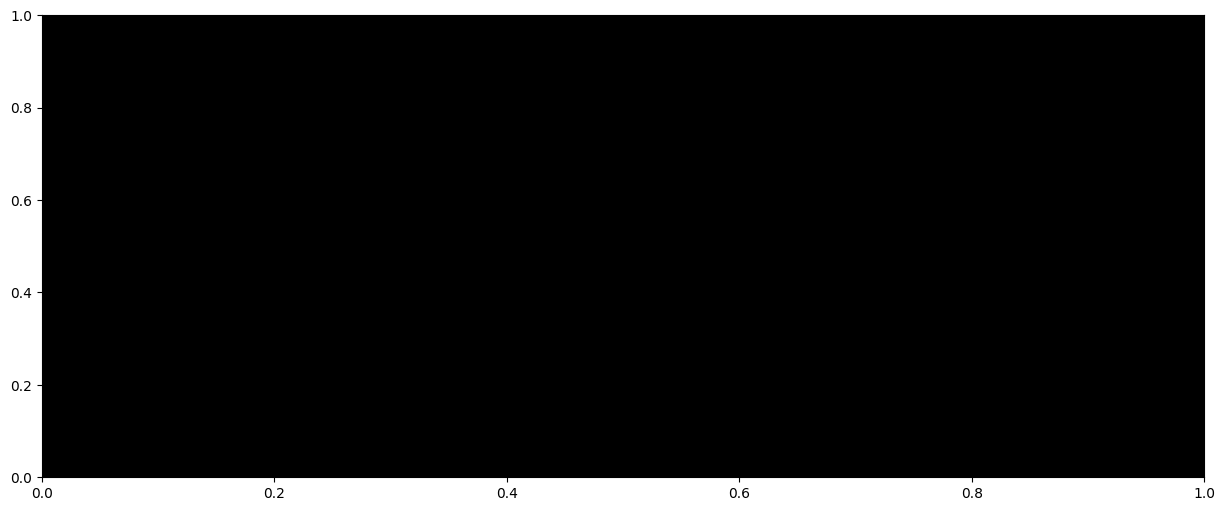

In [ ]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(scaled_sample_df['pickup_longitude'],scaled_sample_df['pickup_latitude'],
           s=0.05,c=sample_predictions)
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

plt.show()